In [ ]:
import os
target = "/content/stk-mat2011/code/data/processed/"
if os.path.exists(target):
    print(f"Files ian processed folder: {os.listdir(target)}")
else:
    print("Folder does not exist!")

Folder does not exist!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Check current location
cwd = os.getcwd()
print(f"Current Working Directory: {cwd}")

# Try to find the 'code/data/processed' directory
if "notebooks" in cwd:
    # We are in stk-mat2011/code/notebooks
    data_dir = "../data/processed/"
else:
    # We are in the root stk-mat2011 folder
    data_dir = "code/data/processed/"

if not os.path.exists(data_dir):
    print(f"⚠️ PATH NOT FOUND: {data_dir}")
    print("Checking alternatives...")
    # Last resort check
    if os.path.exists("/content/stk-mat2011/code/data/processed/"):
        data_dir = "/content/stk-mat2011/code/data/processed/"
        print(f"Colab path found: {data_dir}")

output_dir = data_dir
print(f"Validated Data Directory: {data_dir}")

Current Working Directory: c:\Users\ofurn\Dokumenter\Github\stk-mat2011\code\notebooks
Validated Data Directory: ../data/processed/


In [3]:
""" Load Dukascopy Bid and Ask for Jan 2026 """
# Loading from the 'processed' folder where they are already Parquet
bid_file = os.path.join(data_dir, "eurusd_dukascopy_bid_202601.parquet")
ask_file = os.path.join(data_dir, "eurusd_dukascopy_ask_202601.parquet")

df_bid = pd.read_parquet(bid_file)
df_ask = pd.read_parquet(ask_file)

# We only need datetime and price
df_bid = df_bid[['datetime', 'price']].rename(columns={'price': 'bid'})
df_ask = df_ask[['datetime', 'price']].rename(columns={'price': 'ask'})

print(f"Loaded {len(df_bid):,} Bid ticks and {len(df_ask):,} Ask ticks.")

Loaded 1,506,261 Bid ticks and 1,506,261 Ask ticks.


In [4]:
""" Merge Bid and Ask to get the Mid-Price """
# merge_asof requires sorted data
df_bid = df_bid.sort_values('datetime')
df_ask = df_ask.sort_values('datetime')

# Combine them by matching the nearest bid to every ask
df = pd.merge_asof(df_ask, df_bid, on='datetime', direction='nearest')

# Calculate Mid Price
df['mid'] = (df['bid'] + df['ask']) / 2
df.set_index('datetime', inplace=True)

print(f"Data Synced. Total observations: {len(df):,}")
print(df.head())

Data Synced. Total observations: 1,506,261
                                      ask      bid       mid
datetime                                                    
2026-01-01 22:04:01.135000+00:00  1.17532  1.17387  1.174595
2026-01-01 22:04:37.436000+00:00  1.17531  1.17414  1.174725
2026-01-01 22:05:00.073000+00:00  1.17517  1.17414  1.174655
2026-01-01 22:05:00.283000+00:00  1.17523  1.17449  1.174860
2026-01-01 22:05:01.142000+00:00  1.17518  1.17449  1.174835


In [5]:
""" Clip for Core Trading Hours (08:00 - 17:00) """
df_clipped = df.between_time('08:00', '17:00')

print(f"Clipped for trading hours. Remaining: {len(df_clipped):,} ticks.")

Clipped for trading hours. Remaining: 821,883 ticks.


In [6]:
""" Pre-average and Downsample (K=50) """
K_TICKS = 50

# Rolling mean of K ticks
df_preavg = df_clipped['mid'].rolling(window=K_TICKS).mean()

# Take every K-th point to get a clean, independent series
df_final = df_preavg.iloc[::K_TICKS].dropna().to_frame(name='mid_price')

print(f"Pre-averaging complete. Final dataset size: {len(df_final):,} observations.")

Pre-averaging complete. Final dataset size: 16,437 observations.


In [7]:
""" Calculate Clean Log-Returns for the Models """
df_final['returns'] = np.log(df_final['mid_price']).diff()
df_final = df_final.dropna()

# Extra safety: filter extreme outliers (likely data bad prints)
df_final = df_final[df_final['returns'].abs() < df_final['returns'].std() * 10]

print("Log-Returns calculated and filtered.")

Log-Returns calculated and filtered.


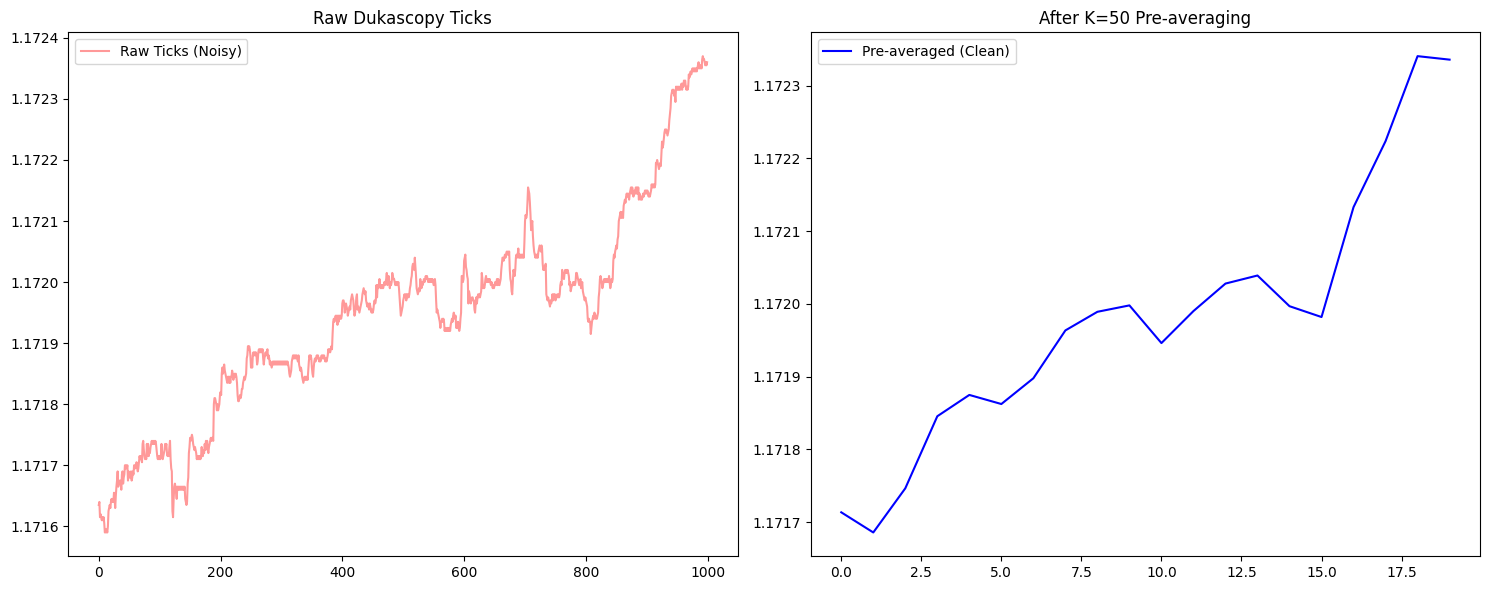

In [8]:
""" Verify Noise Reduction with Plot """
plt.figure(figsize=(15, 6))

# Plot raw vs cleaned for a small slice
start = 10000
raw_slice = df_clipped['mid'].iloc[start : start+1000]
clean_slice = df_final['mid_price'].iloc[start//K_TICKS : (start+1000)//K_TICKS]

plt.subplot(1, 2, 1)
plt.plot(raw_slice.values, color='red', alpha=0.4, label='Raw Ticks (Noisy)')
plt.title("Raw Dukascopy Ticks")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(clean_slice.values, color='blue', label='Pre-averaged (Clean)')
plt.title(f"After K={K_TICKS} Pre-averaging")
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
""" Save Processed Returns """
out_path = os.path.join(output_dir, "eurusd_clean_returns_jan2026.parquet")
df_final.to_parquet(out_path)

print(f"SUCCESS: Data saved to {out_path}")

SUCCESS: Data saved to ../data/processed/eurusd_clean_returns_jan2026.parquet


In [10]:
""" Final Summary of Pre-processing """
print("=" * 80)
print("REAL DATA PREPARATION SUMMARY".center(80))
print("=" * 80)
print(f"  Source: Dukascopy Jan 2026 (Bid/Ask)")
print(f"  Initial Ticks: {len(df):,}")
print(f"  Trading Hours: 08:00 - 17:00")
print(f"  Pre-averaging (K): {K_TICKS}")
print(f"  Final Observations: {len(df_final):,}")
print("-" * 80)
print(f"  Sample Mean: {df_final['returns'].mean():.8f}")
print(f"  Sample Std: {df_final['returns'].std():.8f}")
print(f"  Sample Vol (Daily Annualized): {df_final['returns'].std() * np.sqrt(252 * 50):.4f}")
print("=" * 80)

                         REAL DATA PREPARATION SUMMARY                          
  Source: Dukascopy Jan 2026 (Bid/Ask)
  Initial Ticks: 1,506,261
  Trading Hours: 08:00 - 17:00
  Pre-averaging (K): 50
  Final Observations: 16,426
--------------------------------------------------------------------------------
  Sample Mean: 0.00000011
  Sample Std: 0.00009070
  Sample Vol (Daily Annualized): 0.0102
